<a target="_blank" href="https://colab.research.google.com/github/jvictorferreira3301/metodos-numericos/blob/main/M%C3%A9todos_Num%C3%A9ricos_Grupo_3.ipynb"> <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho 1: Raízes de Equações

---

## $I$. Métodos Intervalares

### 1. Varredura de possíveis raízes
* Implementar busca incremental de possíveis raízes num intervalo de interesse, com base na seção 5.4, página 113.
* Receber do usuário a expressão da função, o intervalo de interesse e o número N de subdivisões.
* Calcular o sinal da função para cada subdivisão.
* Retornar os subintervalos com mudança de sinal ou zero da função.
* Retornar gráfico mostrando todas as subdivisões e destacando as detecções de mudança de sinal.
* Solicitar ao usuário se deseja refinar N ou proceder para o cálculo.

MÉTODO 1: VARREDURA DE POSSÍVEIS RAÍZES

1. ENTRADA DE DADOS
------------------------------------------------------------

2. CÁLCULO DAS SUBDIVISÕES
------------------------------------------------------------

Tabela de Subdivisões:
 Ponto    f(x)    Sinal
  -2.0 -24.000 Negativo
  -1.5 -11.875 Negativo
  -1.0  -4.000 Negativo
  -0.5   0.375 Positivo
   0.0   2.000 Positivo
   0.5   1.625 Positivo
   1.0   0.000     Zero
   1.5  -2.125 Negativo
   2.0  -4.000 Negativo
   2.5  -4.875 Negativo
   3.0  -4.000 Negativo
   3.5  -0.625 Negativo
   4.0   6.000 Positivo
   4.5  16.625 Positivo
   5.0  32.000 Positivo

3. DETECÇÃO DE MUDANÇAS DE SINAL
------------------------------------------------------------

Total de possíveis raízes detectadas: 3

Subintervalos com possíveis raízes:
 Inicio  Fim  f(inicio)  f(fim)             Tipo
   -1.0 -0.5     -4.000   0.375 Mudança de Sinal
    1.0  1.0      0.000   0.000  Zero Encontrado
    3.5  4.0     -0.625   6.000 Mudança de Sinal

4. VISUALIZ

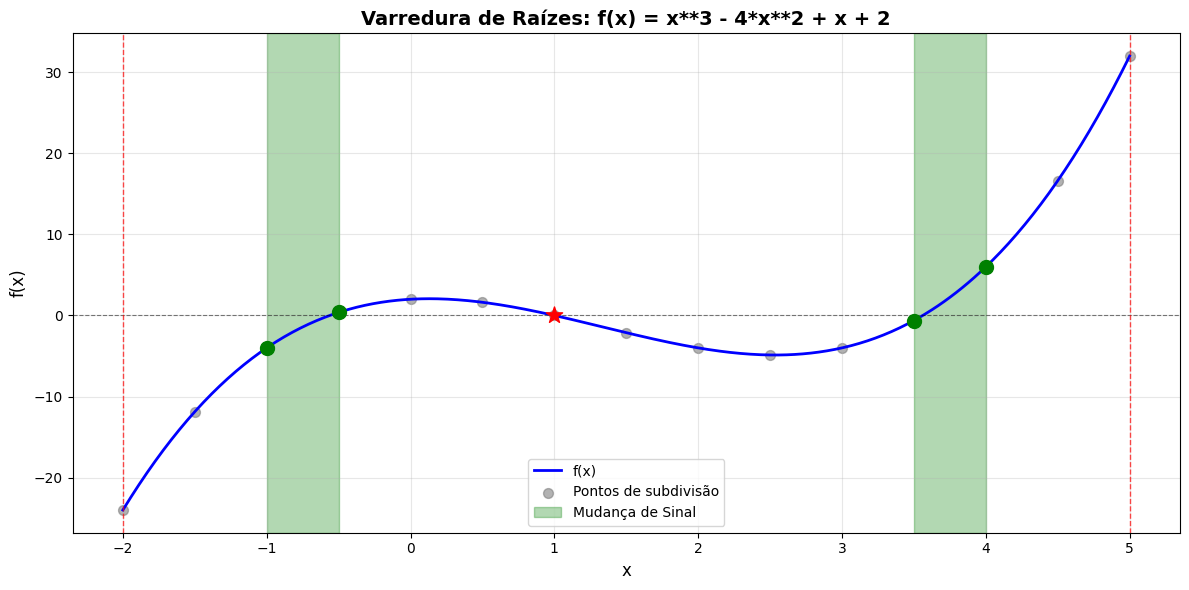


5. REFINAMENTO E PRÓXIMOS PASSOS
------------------------------------------------------------

Opções:
1. Refinar a busca com um novo valor de N
2. Prosseguir para o cálculo de raízes (Método da Bisseção)
3. Sair

Próxima etapa: Execute a próxima célula para calcular raízes com o método da bisseção.
Intervalos disponíveis para cálculo guardados na memória.


'\n# Cenário 1: Polinômio com múltiplas raízes\nx**3 - 4*x**2 + x + 2\n-2\n5\n14\n\n# Cenário 2: Função Trigonométrica\nsin(x) - 0.5\n0\n6\n12\n\n# Cenário 3: Teste de "Zero Exato"\nx**2 - 4\n0\n4\n4\n'

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, lambdify, sympify
import pandas as pd

def busca_incremental_raizes():
    """
    Implementa a busca incremental de possíveis raízes num intervalo.
    Baseado na seção 5.4, página 113.
    Retorna uma tupla: (lista_de_intervalos_detectados, expressao_em_string)
    """
    print("="*60)
    print("MÉTODO 1: VARREDURA DE POSSÍVEIS RAÍZES")
    print("="*60)
    
    # Etapa 1: Receber entrada do usuário
    print("\n1. ENTRADA DE DADOS")
    print("-" * 60)
    
    expr_str = input("Insira a expressão da função f(x): ").strip()
    intervalo_1 = float(input("Insira a primeira extremidade do intervalo: "))
    intervalo_2 = float(input("Insira a segunda extremidade do intervalo: "))
    N = int(input("Insira o número N de subdivisões: "))
    
    # Validar intervalo
    if intervalo_1 > intervalo_2:
        intervalo_1, intervalo_2 = intervalo_2, intervalo_1
    
    # Converter string para função
    x = symbols('x')
    try:
        expr = sympify(expr_str)
        f = lambdify(x, expr, 'numpy')
    except:
        print("Erro: Expressão inválida!")
        return None, None
    
    # Etapa 2: Calcular pontos de subdivisão
    print("\n2. CÁLCULO DAS SUBDIVISÕES")
    print("-" * 60)
    
    pontos = np.linspace(intervalo_1, intervalo_2, N + 1)
    valores_funcao = f(pontos)
    
    # Criar tabela de subdivisões
    dados_subdivisoes = pd.DataFrame({
        'Ponto': pontos,
        'f(x)': valores_funcao,
        'Sinal': ['Positivo' if v > 0 else 'Negativo' if v < 0 else 'Zero' for v in valores_funcao]
    })
    
    print("\nTabela de Subdivisões:")
    print(dados_subdivisoes.to_string(index=False))
    
    # Etapa 3: Detectar mudanças de sinal
    print("\n3. DETECÇÃO DE MUDANÇAS DE SINAL")
    print("-" * 60)
    
    subintervalos_raizes = []
    
    for i in range(len(pontos) - 1):
        if valores_funcao[i] * valores_funcao[i+1] < 0:
            subintervalos_raizes.append({
                'Inicio': pontos[i],
                'Fim': pontos[i+1],
                'f(inicio)': valores_funcao[i],
                'f(fim)': valores_funcao[i+1],
                'Tipo': 'Mudança de Sinal'
            })
        elif valores_funcao[i] == 0:
            subintervalos_raizes.append({
                'Inicio': pontos[i],
                'Fim': pontos[i],
                'f(inicio)': valores_funcao[i],
                'f(fim)': valores_funcao[i],
                'Tipo': 'Zero Encontrado'
            })
    
    if valores_funcao[-1] == 0:
        subintervalos_raizes.append({
            'Inicio': pontos[-1],
            'Fim': pontos[-1],
            'f(inicio)': valores_funcao[-1],
            'f(fim)': valores_funcao[-1],
            'Tipo': 'Zero Encontrado'
        })
    
    print(f"\nTotal de possíveis raízes detectadas: {len(subintervalos_raizes)}")
    
    if subintervalos_raizes:
        df_raizes = pd.DataFrame(subintervalos_raizes)
        print("\nSubintervalos com possíveis raízes:")
        print(df_raizes.to_string(index=False))
    else:
        print("Nenhuma raiz detectada neste intervalo!")
    
    # Etapa 4: Plotar gráfico
    print("\n4. VISUALIZAÇÃO GRÁFICA")
    print("-" * 60)
    
    x_plot = np.linspace(intervalo_1, intervalo_2, 500)
    y_plot = f(x_plot)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(x_plot, y_plot, 'b-', linewidth=2, label='f(x)')
    ax.scatter(pontos, valores_funcao, color='gray', s=50, alpha=0.6, label='Pontos de subdivisão')
    
    for raiz in subintervalos_raizes:
        if raiz['Tipo'] == 'Mudança de Sinal':
            ax.axvspan(raiz['Inicio'], raiz['Fim'], alpha=0.3, color='green', label='Mudança de Sinal' if raiz == subintervalos_raizes[0] else '')
            ax.scatter([raiz['Inicio'], raiz['Fim']], [raiz['f(inicio)'], raiz['f(fim)']], 
                      color='green', s=100, marker='o', zorder=5)
        elif raiz['Tipo'] == 'Zero Encontrado':
            ax.scatter([raiz['Inicio']], [raiz['f(inicio)']], 
                      color='red', s=150, marker='*', zorder=5, label='Zero Encontrado' if raiz == subintervalos_raizes[0] else '')
    
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axvline(x=intervalo_1, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.axvline(x=intervalo_2, color='red', linestyle='--', linewidth=1, alpha=0.7)
    
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('f(x)', fontsize=12)
    ax.set_title(f'Varredura de Raízes: f(x) = {expr_str}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')
    
    plt.tight_layout()
    plt.show()
    
    # Etapa 5: Oferecer opções de refinamento
    print("\n5. REFINAMENTO E PRÓXIMOS PASSOS")
    print("-" * 60)
    print("\nOpções:")
    print("1. Refinar a busca com um novo valor de N")
    print("2. Prosseguir para o cálculo de raízes (Método da Bisseção)")
    print("3. Sair")
    
    opcao = input("\nEscolha uma opção (1, 2 ou 3): ").strip()
    
    if opcao == '1':
        print("\nRetornando para refinar a busca...")
        return busca_incremental_raizes()
    elif opcao == '2':
        print("\nPróxima etapa: Execute a próxima célula para calcular raízes com o método da bisseção.")
        if subintervalos_raizes:
            print("Intervalos disponíveis para cálculo guardados na memória.")
        return subintervalos_raizes, expr_str
    else:
        print("\nSaída do programa.")
        return None, None

# Executar o programa e salvar as variáveis globalmente
# Desempacotar a tupla gerada na opção 2.
try:
    resultado_varredura, expressao_funcao = busca_incremental_raizes()
except ValueError:
    pass # Tratamento para caso ocorra interrupção inexperada

'''
# Cenário 1: Polinômio com múltiplas raízes
x**3 - 4*x**2 + x + 2
-2
5
14

# Cenário 2: Função Trigonométrica
sin(x) - 0.5
0
6
12

# Cenário 3: Teste de "Zero Exato"
x**2 - 4
0
4
4
'''

### 2. Método da Bisseção
* Implementar rotina para calcular as raízes detectadas na varredura via método da bisseção.
* Receber do usuário o nível de precisão (tolerância).
* Mostrar tabela com resultados de todas as iterações.
* A tabela deve conter: número da iteração, valor da esquerda, valor da direita, ponto médio e valor da função no ponto médio.
* Solicitar ao usuário se deseja repetir o processo para a próxima raiz, caso mais de uma tenha sido detectada.

In [ ]:
import numpy as np
import pandas as pd
from sympy import symbols, lambdify, sympify

def metodo_bisseccao(f, a, b, tolerancia, max_iteracoes=100):
    """
    Implementa o método da bisseção para encontrar raízes.
    
    Parâmetros:
    - f: função
    - a, b: extremidades do intervalo
    - tolerancia: critério de convergência
    - max_iteracoes: número máximo de iterações
    
    Retorna:
    - DataFrame com histórico de iterações
    - raiz aproximada
    """
    
    # Validar intervalo
    if f(a) * f(b) > 0:
        print("Erro: A função não muda de sinal no intervalo [a, b]!")
        return None, None
    
    iteracoes = []
    iteracao = 0
    
    # Garantir que a < b
    if a > b:
        a, b = b, a
    
    while (b - a) > tolerancia and iteracao < max_iteracoes:
        c = (a + b) / 2  # Ponto médio
        fc = f(c)
        
        iteracoes.append({
            'Iteração': iteracao + 1,
            'a (Esquerda)': a,
            'b (Direita)': b,
            'c (Ponto Médio)': c,
            'f(c)': fc,
            'Erro Absoluto': (b - a) / 2
        })
        
        # Atualizar intervalo baseado no sinal
        if f(a) * fc < 0:
            b = c  # Raiz está em [a, c]
        else:
            a = c  # Raiz está em [c, b]
        
        iteracao += 1
    
    # Último ponto
    c = (a + b) / 2
    fc = f(c)
    iteracoes.append({
        'Iteração': iteracao + 1,
        'a (Esquerda)': a,
        'b (Direita)': b,
        'c (Ponto Médio)': c,
        'f(c)': fc,
        'Erro Absoluto': (b - a) / 2
    })
    
    df_iteracoes = pd.DataFrame(iteracoes)
    return df_iteracoes, c

def executor_bisseccao(subintervalos_raizes, f_str):
    """
    Executa o método da bisseção para todos os intervalos detectados.
    """
    if not subintervalos_raizes:
        print("\nNenhum intervalo com raiz disponível!")
        return
    
    print("\n" + "="*80)
    print("MÉTODO 2: MÉTODO DA BISSEÇÃO")
    print("="*80)
    
    # Receber tolerância do usuário
    print("\nInserção de Parâmetro:")
    print("-" * 80)
    try:
        tolerancia = float(input("Insira a tolerância (precisão) desejada: "))
        if tolerancia <= 0:
            print("Erro: Tolerância deve ser positiva!")
            return
    except:
        print("Erro: Valor inválido para tolerância!")
        return
    
    # Converter string para função
    x = symbols('x')
    try:
        expr = sympify(f_str)
        f = lambdify(x, expr, 'numpy')
    except:
        print("Erro: Expressão inválida!")
        return
    
    resultados_totais = []
    
    for idx, intervalo in enumerate(subintervalos_raizes, 1):
        print(f"\n{'='*80}")
        print(f"Raiz #{idx} - Intervalo: [{intervalo['Inicio']:.6f}, {intervalo['Fim']:.6f}]")
        print(f"{'='*80}")
        
        a = intervalo['Inicio']
        b = intervalo['Fim']
        
        # Executar bisseção
        df_resultado, raiz_aprox = metodo_bisseccao(f, a, b, tolerancia)
        
        if df_resultado is not None and len(df_resultado) > 0:
            print(f"\nTabela de Iterações:")
            print(df_resultado.to_string(index=False))
            
            print(f"\n{'─'*80}")
            print(f"Resultado Final:")
            print(f"  Raiz Aproximada: {raiz_aprox:.10f}")
            print(f"  f(raiz): {f(raiz_aprox):.2e}")
            print(f"  Número de Iterações: {len(df_resultado) - 1}")
            print(f"  Erro Absoluto Final: {df_resultado['Erro Absoluto'].iloc[-1]:.2e}")
            print(f"{'─'*80}")
            
            resultados_totais.append({
                'Raiz #': idx,
                'Raiz Aproximada': raiz_aprox,
                'f(raiz)': f(raiz_aprox),
                'Iterações': len(df_resultado) - 1,
                'Tolerância': tolerancia
            })
            
            # Perguntar se deseja continuar para próxima raiz
            if idx < len(subintervalos_raizes):
                continuar = input("\nDeseja continuar para a próxima raiz? (s/n): ").strip().lower()
                if continuar != 's':
                    print("\nExecução interrompida pelo usuário.")
                    break
        else:
            print(f"Não foi possível calcular a raiz neste intervalo.")
    
    # Resumo final
    if resultados_totais:
        print(f"\n{'='*80}")
        print("RESUMO DE TODAS AS RAÍZES CALCULADAS")
        print(f"{'='*80}")
        df_resumo = pd.DataFrame(resultados_totais)
        print(df_resumo.to_string(index=False))
        print(f"{'='*80}\n")
    
    return resultados_totais

# =====================================================================
# EXECUÇÃO PROCEDURAL DO MÉTODO DA BISSEÇÃO
# =====================================================================
# Verifica se a varredura foi executada e as variáveis estão salvas no Notebook
if 'resultado_varredura' in locals() and resultado_varredura is not None:
    resultados_bisseccao = executor_bisseccao(resultado_varredura, expressao_funcao)
else:
    print("Aviso: Variáveis da varredura não encontradas.")
    print("Por favor, execute a célula 'Varredura de possíveis raízes' PRIMEIRO e escolha a OPÇÃO 2.")



MÉTODO 2: MÉTODO DA BISSEÇÃO

Inserção de Parâmetro:
--------------------------------------------------------------------------------

Raiz #1 - Intervalo: [-1.000000, -0.500000]

Tabela de Iterações:
 Iteração  a (Esquerda)  b (Direita)  c (Ponto Médio)      f(c)  Erro Absoluto
        1       -1.0000    -0.500000        -0.750000 -1.421875       0.250000
        2       -0.7500    -0.500000        -0.625000 -0.431641       0.125000
        3       -0.6250    -0.500000        -0.562500 -0.006104       0.062500
        4       -0.5625    -0.500000        -0.531250  0.189911       0.031250
        5       -0.5625    -0.531250        -0.546875  0.093281       0.015625
        6       -0.5625    -0.546875        -0.554688  0.043934       0.007812
        7       -0.5625    -0.554688        -0.558594  0.019002       0.003906
        8       -0.5625    -0.558594        -0.560547  0.006471       0.001953
        9       -0.5625    -0.560547        -0.561523  0.000189       0.000977
       1

### 3. Método da Falsa posição
* Implementar rotina semelhante à da bisseção, aplicando o método da falsa posição.

In [ ]:
import numpy as np
import pandas as pd
from sympy import symbols, lambdify, sympify

def metodo_falsa_posicao(f, a, b, tolerancia, max_iteracoes=100):
    """
    Implementa o método da falsa posição para encontrar raízes.
    
    Parâmetros:
    - f: função
    - a, b: extremidades do intervalo
    - tolerancia: critério de convergência (baseado na variação de c)
    - max_iteracoes: número máximo de iterações
    
    Retorna:
    - DataFrame com histórico de iterações
    - raiz aproximada
    """
    
    # Validar se existe raiz no intervalo
    if f(a) * f(b) > 0:
        print("Erro: A função não muda de sinal no intervalo [a, b]!")
        return None, None
    
    iteracoes = []
    iteracao = 0
    c_old = a
    erro = abs(b - a)
    
    # Na falsa posição um dos limites pode permanecer estático. 
    # Usamos o erro absoluto focado na mudança de 'c' entre as iterações.
    while erro > tolerancia and iteracao < max_iteracoes:
        fa = f(a)
        fb = f(b)
        
        # Evitar divisão por zero na fórmula
        if fb - fa == 0:
            print("Erro: Divisão por zero na fórmula da Falsa Posição.")
            break
            
        # Fórmula da Falsa Posição
        c = (a * fb - b * fa) / (fb - fa)
        fc = f(c)
        
        # O erro absoluto a partir da 2ª iteração é a diferença entre o c atual e o anterior
        if iteracao > 0:
            erro = abs(c - c_old)
            
        iteracoes.append({
            'Iteração': iteracao + 1,
            'a (Esquerda)': a,
            'b (Direita)': b,
            'c (Falsa Posição)': c,
            'f(c)': fc,
            'Erro Absoluto': erro
        })
        
        # Atualizar intervalo baseado no sinal
        if fa * fc < 0:
            b = c  # Raiz está em [a, c]
        else:
            a = c  # Raiz está em [c, b]
            
        c_old = c
        iteracao += 1
        
        # Condição de parada de segurança caso chegue à raiz exata
        if abs(fc) < 1e-15:
            break
            
    df_iteracoes = pd.DataFrame(iteracoes)
    return df_iteracoes, c_old

def executor_falsa_posicao(subintervalos_raizes, f_str):
    """
    Executa o método da falsa posição iterando por todos os intervalos detectados.
    """
    if not subintervalos_raizes:
        print("\nNenhum intervalo com raiz disponível!")
        return
    
    print("\n" + "="*80)
    print("MÉTODO 3: MÉTODO DA FALSA POSIÇÃO")
    print("="*80)
    
    # Receber tolerância do usuário (Requisito 2.2 / 3.1)
    print("\nInserção de Parâmetro:")
    print("-" * 80)
    try:
        tolerancia = float(input("Insira o nível de precisão (tolerância) desejado: "))
        if tolerancia <= 0:
            print("Erro: Tolerância deve ser positiva!")
            return
    except:
        print("Erro: Valor numérico inválido para tolerância!")
        return
    
    # Converter string para função utilizando SymPy
    x = symbols('x')
    try:
        expr = sympify(f_str)
        f = lambdify(x, expr, 'numpy')
    except:
        print("Erro: Expressão inválida!")
        return
    
    resultados_totais = []
    
    for idx, intervalo in enumerate(subintervalos_raizes, 1):
        print(f"\n{'='*80}")
        print(f"Raiz #{idx} - Intervalo: [{intervalo['Inicio']:.6f}, {intervalo['Fim']:.6f}]")
        print(f"{'='*80}")
        
        a = intervalo['Inicio']
        b = intervalo['Fim']
        
        # Executar falsa posição
        df_resultado, raiz_aprox = metodo_falsa_posicao(f, a, b, tolerancia)
        
        if df_resultado is not None and len(df_resultado) > 0:
            # Exibir Tabela (Requisito 2.3 / 3.1)
            print(f"\nTabela de Iterações:")
            print(df_resultado.to_string(index=False))
            
            print(f"\n{'─'*80}")
            print(f"Resultado Final:")
            print(f"  Raiz Aproximada: {raiz_aprox:.10f}")
            print(f"  f(raiz): {f(raiz_aprox):.2e}")
            print(f"  Número de Iterações: {len(df_resultado)}")
            print(f"  Erro Absoluto Final: {df_resultado['Erro Absoluto'].iloc[-1]:.2e}")
            print(f"{'─'*80}")
            
            resultados_totais.append({
                'Raiz #': idx,
                'Raiz Aproximada': raiz_aprox,
                'f(raiz)': f(raiz_aprox),
                'Iterações': len(df_resultado),
                'Tolerância': tolerancia
            })
            
            # Solicitar continuação caso haja mais raízes detectadas (Requisito 2.3 / 3.1)
            if idx < len(subintervalos_raizes):
                continuar = input("\nDeseja repetir o processo para a próxima raiz? (s/n): ").strip().lower()
                if continuar != 's':
                    print("\nExecução interrompida pelo usuário.")
                    break
        else:
            print(f"Não foi possível calcular a raiz neste intervalo.")
    
    # Resumo final
    if resultados_totais:
        print(f"\n{'='*80}")
        print("RESUMO DE TODAS AS RAÍZES CALCULADAS (FALSA POSIÇÃO)")
        print(f"{'='*80}")
        df_resumo = pd.DataFrame(resultados_totais)
        print(df_resumo.to_string(index=False))
        print(f"{'='*80}\n")
    
    return resultados_totais

# =====================================================================
# EXECUÇÃO PROCEDURAL DO MÉTODO DA FALSA POSIÇÃO
# =====================================================================
# Verifica se a varredura foi executada e as variáveis estão salvas na memória do Notebook
if 'resultado_varredura' in locals() and resultado_varredura is not None:
    resultados_falsa_posicao = executor_falsa_posicao(resultado_varredura, expressao_funcao)
else:
    print("Aviso: Variáveis globais da varredura não encontradas.")
    print("Por favor, suba e execute a célula '1. Varredura de possíveis raízes' PRIMEIRO.")



MÉTODO 3: MÉTODO DA FALSA POSIÇÃO

Inserção de Parâmetro:
--------------------------------------------------------------------------------

Raiz #1 - Intervalo: [-1.000000, -0.500000]

Tabela de Iterações:
 Iteração  a (Esquerda)  b (Direita)  c (Falsa Posição)     f(c)  Erro Absoluto
        1          -1.0    -0.500000          -0.542857 0.118391       0.500000
        2          -1.0    -0.542857          -0.555999 0.035586       0.013141
        3          -1.0    -0.555999          -0.559914 0.010538       0.003915
        4          -1.0    -0.559914          -0.561070 0.003107       0.001156
        5          -1.0    -0.561070          -0.561411 0.000915       0.000341

────────────────────────────────────────────────────────────────────────────────
Resultado Final:
  Raiz Aproximada: -0.5614107240
  f(raiz): 9.15e-04
  Número de Iterações: 5
  Erro Absoluto Final: 3.41e-04
────────────────────────────────────────────────────────────────────────────────

Raiz #2 - Intervalo: [

### 4. Comparação entre os métodos
* Implementar comparação gráfica entre bisseção e falsa posição.
* Mostrar graficamente que o método da falsa posição converge mais rápido, semelhante à figura 5.13 da página 110.

In [7]:
# [Célula de Código: Inserir lógica de sobreposição gráfica e comparação]

### 5. Método da Falsa posição modificado
* Implementar rotina aplicando o método da falsa posição modificado, conforme página 112.

In [13]:
import numpy as np
import pandas as pd
from sympy import symbols, lambdify, sympify

def metodo_falsa_posicao_modificada(f, a, b, tolerancia, max_iteracoes=100):
    """
    Implementa o método da falsa posição modificado para encontrar raízes.
    Evita o problema da "extremidade presa" dividindo f(x) por 2 na extremidade estagnada.
    """
    fa = f(a)
    fb = f(b)
    
    # Validar se existe raiz no intervalo
    if fa * fb > 0:
        print("Erro: A função não muda de sinal no intervalo [a, b]!")
        return None, None
    
    iteracoes = []
    iteracao = 0
    c_old = a
    erro = abs(b - a)
    
    il = 0  # Contador de estagnação para o limite inferior (a)
    iu = 0  # Contador de estagnação para o limite superior (b)
    
    while erro > tolerancia and iteracao < max_iteracoes:
        # Evitar divisão por zero na fórmula
        if fb - fa == 0:
            print("Erro: Divisão por zero na fórmula da Falsa Posição Modificada.")
            break
            
        # Fórmula da Falsa Posição (xr = xu - fu * (xl - xu) / (fl - fu))
        c = b - fb * (a - b) / (fa - fb)
        fc = f(c)
        
        # O erro absoluto a partir da 2ª iteração é a diferença entre o c atual e o anterior
        if iteracao > 0:
            erro = abs(c - c_old)
            
        iteracoes.append({
            'Iteração': iteracao + 1,
            'a (Esquerda)': a,
            'b (Direita)': b,
            'c (Falsa Pos. Mod)': c,
            'f(c)': fc,
            'Erro Absoluto': erro
        })
        
        test = fa * fc
        
        # Lógica de atualização com detecção de extremidade presa
        if test < 0:
            # Raiz está no subintervalo inferior [a, c]
            b = c
            fb = f(b)
            iu = 0
            il += 1
            if il >= 2:
                fa = fa / 2
        elif test > 0:
            # Raiz está no subintervalo superior [c, b]
            a = c
            fa = f(a)
            il = 0
            iu += 1
            if iu >= 2:
                fb = fb / 2
        else:
            # Raiz exata encontrada
            erro = 0
            
        c_old = c
        iteracao += 1
        
        # Condição de parada de segurança
        if abs(fc) < 1e-15:
            break
            
    df_iteracoes = pd.DataFrame(iteracoes)
    return df_iteracoes, c_old

def executor_falsa_posicao_modificada(subintervalos_raizes, f_str):
    """
    Executa o método da falsa posição modificada iterando por todos os intervalos detectados.
    """
    if not subintervalos_raizes:
        print("\nNenhum intervalo com raiz disponível!")
        return
    
    print("\n" + "="*80)
    print("MÉTODO 5: MÉTODO DA FALSA POSIÇÃO MODIFICADO")
    print("="*80)
    
    print("\nInserção de Parâmetro:")
    print("-" * 80)
    try:
        tolerancia = float(input("Insira o nível de precisão (tolerância) desejado: "))
        if tolerancia <= 0:
            print("Erro: Tolerância deve ser positiva!")
            return
    except:
        print("Erro: Valor numérico inválido para tolerância!")
        return
    
    # Converter string para função utilizando SymPy
    x = symbols('x')
    try:
        expr = sympify(f_str)
        f = lambdify(x, expr, 'numpy')
    except:
        print("Erro: Expressão inválida!")
        return
    
    resultados_totais = []
    
    for idx, intervalo in enumerate(subintervalos_raizes, 1):
        print(f"\n{'='*80}")
        print(f"Raiz #{idx} - Intervalo: [{intervalo['Inicio']:.6f}, {intervalo['Fim']:.6f}]")
        print(f"{'='*80}")
        
        a = intervalo['Inicio']
        b = intervalo['Fim']
        
        # Executar falsa posição modificada
        df_resultado, raiz_aprox = metodo_falsa_posicao_modificada(f, a, b, tolerancia)
        
        if df_resultado is not None and len(df_resultado) > 0:
            print(f"\nTabela de Iterações:")
            print(df_resultado.to_string(index=False))
            
            print(f"\n{'─'*80}")
            print(f"Resultado Final:")
            print(f"  Raiz Aproximada: {raiz_aprox:.10f}")
            print(f"  f(raiz): {f(raiz_aprox):.2e}")
            print(f"  Número de Iterações: {len(df_resultado)}")
            print(f"  Erro Absoluto Final: {df_resultado['Erro Absoluto'].iloc[-1]:.2e}")
            print(f"{'─'*80}")
            
            resultados_totais.append({
                'Raiz #': idx,
                'Raiz Aproximada': raiz_aprox,
                'f(raiz)': f(raiz_aprox),
                'Iterações': len(df_resultado),
                'Tolerância': tolerancia
            })
            
            if idx < len(subintervalos_raizes):
                continuar = input("\nDeseja repetir o processo para a próxima raiz? (s/n): ").strip().lower()
                if continuar != 's':
                    print("\nExecução interrompida pelo usuário.")
                    break
        else:
            print(f"Não foi possível calcular a raiz neste intervalo.")
    
    if resultados_totais:
        print(f"\n{'='*80}")
        print("RESUMO DE TODAS AS RAÍZES CALCULADAS (FALSA POSIÇÃO MODIFICADA)")
        print(f"{'='*80}")
        df_resumo = pd.DataFrame(resultados_totais)
        print(df_resumo.to_string(index=False))
        print(f"{'='*80}\n")
    
    return resultados_totais

# =====================================================================
# EXECUÇÃO PROCEDURAL DO MÉTODO
# =====================================================================
# Verifica se a varredura foi executada e as variáveis estão salvas na memória do Notebook
if 'resultado_varredura' in locals() and resultado_varredura is not None:
    resultados_falsa_posicao_modificada = executor_falsa_posicao_modificada(resultado_varredura, expressao_funcao)
else:
    print("Aviso: Variáveis globais da varredura não encontradas.")
    print("Por favor, suba e execute a célula '1. Varredura de possíveis raízes' PRIMEIRO.")



MÉTODO 5: MÉTODO DA FALSA POSIÇÃO MODIFICADO

Inserção de Parâmetro:
--------------------------------------------------------------------------------

Raiz #1 - Intervalo: [-1.000000, -0.500000]

Tabela de Iterações:
 Iteração  a (Esquerda)  b (Direita)  c (Falsa Pos. Mod)      f(c)  Erro Absoluto
        1          -1.0    -0.500000           -0.542857  0.118391       0.500000
        2          -1.0    -0.542857           -0.555999  0.035586       0.013141
        3          -1.0    -0.555999           -0.563760 -0.014242       0.007762

────────────────────────────────────────────────────────────────────────────────
Resultado Final:
  Raiz Aproximada: -0.5637604787
  f(raiz): -1.42e-02
  Número de Iterações: 3
  Erro Absoluto Final: 7.76e-03
────────────────────────────────────────────────────────────────────────────────

Raiz #2 - Intervalo: [1.000000, 1.000000]
Não foi possível calcular a raiz neste intervalo.

Raiz #3 - Intervalo: [3.500000, 4.000000]

Tabela de Iterações:
 Iter

### 6. Integração entre os métodos
* Implementar rotina que recebe intervalos de interesse da varredura.
* Calcular raízes usando bisseção, falsa posição e falsa posição modificado.
* Construir uma tabela por raiz por método com todas as iterações.
* Imprimir mensagem informando qual método precisou de menos iterações para cada raiz.

In [9]:
# [Célula de Código: Inserir orquestrador dos métodos e tabelas comparativas]

### 7. Testes de consistência
* Mostrar exemplos do funcionamento dos códigos com funções elementares definidas pelo grupo.

In [10]:
import numpy as np
import pandas as pd
from IPython.display import display

def executar_testes_consistencia():
    """
    Executa testes de consistência utilizando funções elementares
    para comparar a bisseção, falsa posição e falsa posição modificada.
    """
    print("="*90)
    print("7. TESTES DE CONSISTÊNCIA: COMPARAÇÃO DOS MÉTODOS INTERVALARES")
    print("="*90)
    
    # Definição das funções elementares a critério do grupo
    # Incluímos funções polinomiais, trigonométricas e exponenciais (comuns em PDS e modelagem).
    testes = [
        {
            'nome': '1. Polinomial: f(x) = x³ - 9x + 3',
            'f': lambda x: x**3 - 9*x + 3,
            'a': 0.0,
            'b': 1.0,
            'tol': 1e-4
        },
        {
            'nome': '2. Trigonométrica: f(x) = cos(x) - x',
            'f': lambda x: np.cos(x) - x,
            'a': 0.0,
            'b': 1.0,
            'tol': 1e-4
        },
        {
            'nome': '3. Exponencial: f(x) = e^(-x) - x',
            'f': lambda x: np.exp(-x) - x,
            'a': 0.0,
            'b': 1.0,
            'tol': 1e-4
        }
    ]
    
    resultados = []
    
    # Verificar se as funções dos métodos anteriores estão carregadas na memória
    metodos_disponiveis = True
    for func_name in ['metodo_bisseccao', 'metodo_falsa_posicao', 'metodo_falsa_posicao_modificada']:
        if func_name not in globals():
            print(f"Erro: A função '{func_name}' não foi encontrada.")
            metodos_disponiveis = False
            
    if not metodos_disponiveis:
        print("Por favor, certifique-se de executar as células dos itens 2, 3 e 5 antes de rodar este teste.")
        return

    # Executar os testes
    for teste in testes:
        f = teste['f']
        a = teste['a']
        b = teste['b']
        tol = teste['tol']
        
        # 1. Bisseção
        df_bis, raiz_bis = metodo_bisseccao(f, a, b, tol)
        iter_bis = len(df_bis) - 1 if df_bis is not None else 'N/A'
        
        # 2. Falsa Posição
        df_fp, raiz_fp = metodo_falsa_posicao(f, a, b, tol)
        iter_fp = len(df_fp) - 1 if df_fp is not None else 'N/A'
        
        # 3. Falsa Posição Modificada
        df_fpm, raiz_fpm = metodo_falsa_posicao_modificada(f, a, b, tol)
        iter_fpm = len(df_fpm) - 1 if df_fpm is not None else 'N/A'
        
        resultados.append({
            'Função Elementar': teste['nome'],
            'Intervalo': f"[{a}, {b}]",
            'Tolerância': tol,
            'Raiz Encontrada (~approx)': round(raiz_bis, 6) if raiz_bis is not None else 'Erro',
            'Iterações (Bisseção)': iter_bis,
            'Iterações (Falsa Pos)': iter_fp,
            'Iterações (Falsa Pos Mod)': iter_fpm
        })

    # Criar um DataFrame estilizado para exibir os resultados
    df_resultados = pd.DataFrame(resultados)
    
    # Exibir resultados no terminal de forma legível
    for _, row in df_resultados.iterrows():
        print(f"\n{row['Função Elementar']}")
        print(f"Intervalo: {row['Intervalo']} | Tolerância: {row['Tolerância']}")
        print(f"Raiz convergida em aproximadamente: {row['Raiz Encontrada (~approx)']}")
        print("-" * 40)
        print(f"Bisseção               -> {row['Iterações (Bisseção)']:>3} iterações")
        print(f"Falsa Posição          -> {row['Iterações (Falsa Pos)']:>3} iterações")
        print(f"Falsa Posição Mod.     -> {row['Iterações (Falsa Pos Mod)']:>3} iterações")
    
    print("\n" + "="*90)
    print("CONCLUSÃO DOS TESTES:")
    print("1. Consistência: Todos os métodos convergiram para o mesmo valor de raiz.")
    print("2. Desempenho: Observa-se que a Falsa Posição Modificada tende a ser mais eficiente,")
    print("   resolvendo o problema da 'extremidade presa' que afeta a Falsa Posição comum.")
    print("="*90)

# Chamar a função de teste
executar_testes_consistencia()

7. TESTES DE CONSISTÊNCIA: COMPARAÇÃO DOS MÉTODOS INTERVALARES

1. Polinomial: f(x) = x³ - 9x + 3
Intervalo: [0.0, 1.0] | Tolerância: 0.0001
Raiz convergida em aproximadamente: 0.337616
----------------------------------------
Bisseção               ->  14 iterações
Falsa Posição          ->   3 iterações
Falsa Posição Mod.     ->   4 iterações

2. Trigonométrica: f(x) = cos(x) - x
Intervalo: [0.0, 1.0] | Tolerância: 0.0001
Raiz convergida em aproximadamente: 0.739105
----------------------------------------
Bisseção               ->  14 iterações
Falsa Posição          ->   4 iterações
Falsa Posição Mod.     ->   4 iterações

3. Exponencial: f(x) = e^(-x) - x
Intervalo: [0.0, 1.0] | Tolerância: 0.0001
Raiz convergida em aproximadamente: 0.567169
----------------------------------------
Bisseção               ->  14 iterações
Falsa Posição          ->   4 iterações
Falsa Posição Mod.     ->   4 iterações

CONCLUSÃO DOS TESTES:
1. Consistência: Todos os métodos convergiram para o mesmo 

### 8. Resolução de exercícios (Parte I)
* Resolver os problemas 5.1, 5.2, 5.3, 5.4, 5.5 e 5.13 da página 114 utilizando os programas desenvolvidos.

In [11]:
# [Células de Código: Inserir resolução de cada problema]

---

In [4]:
%pip install ipywidgets

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## $II$. Métodos Abertos

### 9. Método da iteração de ponto fixo simples
* Implementar rotina que calcule raízes pelo método de ponto fixo simples.
* Receber expressão, chute inicial e tolerância.
* Plotar o gráfico da função.
* Construir tabela exibindo número da iteração, novo x_i e valor da função em x_i.
* Construir gráfico mostrando a convergência ou divergência, conforme Figura 6.3 da página 119.
* Incluir limitador interno de iterações não controlado pelo usuário.
* Implementar acompanhamento interativo das iterações, como um controle deslizante.
* Alertar com exemplo caso o método esteja divergindo.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sympy import symbols, lambdify, sympify
import ipywidgets as widgets
from IPython.display import display

def metodo_ponto_fixo():
    """
    Implementa o método da iteração de ponto fixo simples.
    Requisitos 9.1, 9.2, 9.3 e 9.4.
    """
    print("="*80)
    print("9. MÉTODO DA ITERAÇÃO DE PONTO FIXO SIMPLES")
    print("="*80)
    
    # 9.1: Entrada de dados
    expr_str = input("Insira a expressão da função iterativa g(x) (onde x = g(x)): ").strip()
    try:
        x0 = float(input("Insira o valor do chute inicial (x0): "))
        tolerancia = float(input("Insira a tolerância desejada: "))
    except ValueError:
        print("Erro: Por favor, insira valores numéricos válidos para chute e tolerância!")
        return

    # Converter expressão SymPy
    x_sym = symbols('x')
    try:
        expr = sympify(expr_str)
        g = lambdify(x_sym, expr, 'numpy')
    except Exception as e:
        print(f"Erro ao avaliar a expressão: {e}")
        return

    # 9.3: Limitador interno de iterações (não controlado pelo usuário)
    max_iteracoes = 50 
    
    iteracoes_x = [x0]
    iteracoes_g = [g(x0)]
    
    x_atual = x0
    divergiu = False
    
    for i in range(1, max_iteracoes + 1):
        try:
            x_novo = g(x_atual)
        except Exception:
            # Captura overflow numérico
            divergiu = True
            break
            
        iteracoes_x.append(x_novo)
        iteracoes_g.append(g(x_novo))
        
        # Verificação pragmática de divergência (valores absurdamente altos)
        if abs(x_novo) > 1e10:
            divergiu = True
            break
            
        # Condição de parada de convergência
        if abs(x_novo - x_atual) < tolerancia:
            break
            
        x_atual = x_novo

    # 9.1: Construção da Tabela com saídas
    df_iteracoes = pd.DataFrame({
        'Iteração': range(len(iteracoes_x)),
        'x_i (novo valor)': iteracoes_x,
        'g(x_i) (função)': iteracoes_g
    })
    
    print("\nTabela de Iterações:")
    print("-" * 80)
    print(df_iteracoes.to_string(index=False))
    print("-" * 80)
    
    # Alertar caso o método esteja divergindo
    if divergiu or len(iteracoes_x) > max_iteracoes:
        print("\nALERTA: O método está divergindo ou não atingiu convergência dentro do limite interno!")
        print("Exemplo: A derivada de g(x) possivelmente possui módulo maior que 1 na proximidade da raiz.")
    else:
        print(f"\n✓ Convergência atingida! Raiz aproximada: {iteracoes_x[-1]:.6f}")

    # 9.2 e 9.4: Gráficos e acompanhamento interativo (Controle Deslizante)
    print("\nAcompanhamento Interativo das Iterações (Figura da Teoria)")
    
    def plot_iteracoes(passo):
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Determinar limites para que o plot não quebre em divergências totais
        historico_valido = [v for v in iteracoes_x[:passo+1] if abs(v) < 1e5]
        if not historico_valido:
            print("Valores divergentes demais para plotar!")
            return
            
        x_min = min(historico_valido) - 2
        x_max = max(historico_valido) + 2
        
        x_vals = np.linspace(x_min, x_max, 400)
        
        # Plotar y = x e y = g(x)
        ax.plot(x_vals, x_vals, 'k--', label='y = x', alpha=0.7)
        try:
            ax.plot(x_vals, g(x_vals), 'b-', label=f'y = g(x) = {expr_str}', linewidth=2)
        except:
            print("Erro ao exibir g(x) para os limites estabelecidos.")
            
        # Desenhar o caminho das iterações: linhas verticais e horizontais (Cobweb plot)
        for i in range(passo):
            x_i = iteracoes_x[i]
            x_next = iteracoes_x[i+1]
            
            # Subir/Descer do y=x até a curva g(x)
            ax.plot([x_i, x_i], [x_i, g(x_i)], 'r-', alpha=0.6)
            # Ir horizontalmente da curva g(x) até y=x para formar x_next
            ax.plot([x_i, x_next], [g(x_i), x_next], 'g--', alpha=0.6)
            
            ax.plot(x_i, g(x_i), 'ro', markersize=4)
            
        # Ponto atual destacado
        ax.plot(iteracoes_x[passo], iteracoes_x[passo], 'yo', markersize=8, label=f'x_{passo} atual')
        if passo < len(iteracoes_x) - 1:
            ax.plot(iteracoes_x[passo], g(iteracoes_x[passo]), 'ro', markersize=6)
            
        ax.set_title("Método do Ponto Fixo Simples - Análise de Convergência/Divergência", fontsize=14)
        ax.set_xlabel('x', fontsize=12)
        ax.set_ylabel('y', fontsize=12)
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend()
        plt.tight_layout()
        plt.show()

    # Widget interativo
    slider = widgets.IntSlider(min=0, max=len(iteracoes_x)-1, step=1, value=0, description='Iteração:')
    widgets.interact(plot_iteracoes, passo=slider)

'''
Cenário 1: A Convergência Clássica ("Degraus")
cos(x)
0.5
0.001

Cenário 2: A Convergência Explosiva
x**2 - 2
2.1
0.001

Cenário 3: Convergência em Espiral (Exponencial)
exp(-x)
0
0.001
'''

# Para executar o método, descomente a linha abaixo na hora de testar a célula:
metodo_ponto_fixo()

9. MÉTODO DA ITERAÇÃO DE PONTO FIXO SIMPLES
Erro: Por favor, insira valores numéricos válidos para chute e tolerância!


### 10. Método de Newton-Raphson
* Implementar rotina do método de Newton-Raphson.
* Receber expressão, x_0 e tolerância.
* Plotar gráfico da função e tabela de saídas (iteração, novo x_i, função em x_i).
* Plotar gráfico da função junto com a reta tangente de cada iteração.
* Calcular a derivada da função pelo próprio programa.
* Suspender processo e alertar caso a derivada seja nula em alguma iteração.
* Alertar o usuário sobre possível baixa eficiência se a inclinação estiver abaixo de um limiar.
* Incluir limitador interno de iterações.
* Implementar acompanhamento gráfico interativo das iterações.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sympy import symbols, lambdify, sympify, diff
import ipywidgets as widgets
from IPython.display import display

def metodo_newton_raphson():
    """
    Implementa o método de Newton-Raphson com cálculo automático de derivada,
    tabela de resultados e visualização gráfica interativa das tangentes.
    """
    print("="*80)
    print("10. MÉTODO DE NEWTON-RAPHSON")
    print("="*80)
    
    # Requisito 10.1: Entrada de dados
    print("\n1. ENTRADA DE DADOS")
    print("-" * 80)
    expr_str = input("Insira a expressão da função f(x): ").strip()
    try:
        x0 = float(input("Insira o valor do chute inicial (x_0): "))
        tolerancia = float(input("Insira a tolerância desejada: "))
    except ValueError:
        print("Erro: Por favor, insira valores numéricos válidos para chute e tolerância!")
        return

    # Requisito 10.3: Cálculo da derivada pelo próprio programa
    x_sym = symbols('x')
    try:
        expr = sympify(expr_str)
        expr_deriv = diff(expr, x_sym)  # Calcula a derivada simbolicamente
        
        # Converte para funções utilizáveis com numpy
        f = lambdify(x_sym, expr, 'numpy')
        df = lambdify(x_sym, expr_deriv, 'numpy')
        
        print(f"\nFunção original: f(x) = {expr}")
        print(f"Derivada calculada: f'(x) = {expr_deriv}")
    except Exception as e:
        print(f"Erro ao processar a expressão: {e}")
        return

    # Requisito 10.6: Limitador interno de iterações
    max_iteracoes = 50 
    limiar_inclinacao = 1e-4  # Requisito 10.5
    
    iteracoes = []
    x_atual = x0
    convergiu = False
    
    # Loop de cálculo
    for i in range(max_iteracoes):
        fx = f(x_atual)
        dfx = df(x_atual)
        
        # Grava os dados da iteração atual
        iteracoes.append({
            'Iteração': i,
            'x_i': x_atual,
            'f(x_i)': fx,
            'f\'(x_i)': dfx
        })
        
        # Requisito 10.4: Suspender processo se derivada for nula
        if dfx == 0:
            print(f"\n[!] PROCESSO SUSPENSO: A derivada é exatamente zero na iteração {i} (x = {x_atual}).")
            print("Não é possível continuar pois haverá divisão por zero.")
            break
            
        # Requisito 10.5: Alerta de baixa inclinação (baixa eficiência)
        if abs(dfx) < limiar_inclinacao:
            print(f"\n[AVISO] Inclinação muito baixa (|f'(x)| = {abs(dfx):.2e}) detectada na iteração {i}.")
            print("Isso pode indicar lentidão, divergência ou proximidade de um mínimo/máximo local.")
            
        # Passo de Newton-Raphson
        x_novo = x_atual - (fx / dfx)
        
        # Critério de parada
        if abs(x_novo - x_atual) < tolerancia:
            iteracoes.append({
                'Iteração': i + 1,
                'x_i': x_novo,
                'f(x_i)': f(x_novo),
                'f\'(x_i)': df(x_novo)
            })
            convergiu = True
            break
            
        x_atual = x_novo

    # Requisito 10.1: Tabela com saídas
    df_resultados = pd.DataFrame(iteracoes)
    print("\n2. TABELA DE ITERAÇÕES")
    print("-" * 80)
    print(df_resultados[['Iteração', 'x_i', 'f(x_i)']].to_string(index=False))
    print("-" * 80)
    
    if convergiu:
        print(f"\n✓ Convergência atingida! Raiz aproximada: {iteracoes[-1]['x_i']:.6f}")
    else:
        print("\n[!] O método atingiu o limite interno de iterações sem convergir.")

    # Requisitos 10.2 e 10.7: Plotagem interativa
    print("\n3. ACOMPANHAMENTO GRÁFICO INTERATIVO")
    print("-" * 80)
    
    x_historico = [it['x_i'] for it in iteracoes]
    if not x_historico:
        return
        
    # Definir limites de plotagem baseados no histórico
    margem = max(1.0, (max(x_historico) - min(x_historico)) * 0.5)
    x_min, x_max = min(x_historico) - margem, max(x_historico) + margem
    x_vals = np.linspace(x_min, x_max, 400)
    y_vals = f(x_vals)
    
    def plot_newton(passo):
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Plot da função principal
        ax.plot(x_vals, y_vals, 'b-', linewidth=2, label=f'f(x) = {expr_str}')
        ax.axhline(0, color='black', linewidth=1, alpha=0.7)
        
        # Recuperar dados da iteração atual
        it_atual = iteracoes[passo]
        xi = it_atual['x_i']
        fxi = it_atual['f(x_i)']
        dfxi = it_atual['f\'(x_i)']
        
        # Ponto atual
        ax.plot(xi, fxi, 'ro', markersize=8, label=f'x_{passo} = {xi:.4f}')
        
        # Plot da reta tangente (somente se não for a última iteração onde apenas validamos a raiz)
        if passo < len(iteracoes) - 1 and dfxi != 0:
            x_next = iteracoes[passo+1]['x_i']
            
            # Equação da reta tangente: y = f'(xi)*(x - xi) + f(xi)
            tangent_y = dfxi * (x_vals - xi) + fxi
            ax.plot(x_vals, tangent_y, 'r--', alpha=0.6, label='Reta Tangente')
            
            # Linha tracejada projetando até o eixo x (o novo xi)
            ax.plot([xi, x_next], [fxi, 0], 'g-', alpha=0.8, linewidth=2)
            ax.plot(x_next, 0, 'go', markersize=8, label=f'x_{passo+1} (Projeção)')
            
            # Linha vertical indicando o mapeamento do novo x para a função na próxima iteração
            ax.plot([x_next, x_next], [0, f(x_next)], 'k:', alpha=0.5)
            
        ax.set_xlim([x_min, x_max])
        
        # Ajustar limite Y para não explodir por causa da tangente
        y_hist = [it['f(x_i)'] for it in iteracoes]
        y_margin = max(abs(min(y_hist)), abs(max(y_hist))) * 1.5
        y_margin = max(y_margin, 1) # Margem mínima
        ax.set_ylim([-y_margin, y_margin])
        
        ax.set_title(f"Método de Newton-Raphson - Iteração {passo}", fontsize=14)
        ax.set_xlabel('x', fontsize=12)
        ax.set_ylabel('f(x)', fontsize=12)
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend(loc='best')
        plt.tight_layout()
        plt.show()

    # Widget de controle deslizante
    if len(iteracoes) > 1:
        slider = widgets.IntSlider(min=0, max=len(iteracoes)-1, step=1, value=0, description='Iteração:')
        widgets.interact(plot_newton, passo=slider)
    else:
        plot_newton(0)

'''
# Cenários para Teste:
# 1. Função Suave Clássica:
# f(x): x**2 - 4
# x_0: 5
# tol: 0.001

# 2. Risco de Derivada Zero (Requisito 10.4):
# f(x): x**3 - x
# x_0: 0.57735 (Aproximadamente raiz de 1/3, onde o ponto de inflexão/derivada zero ocorre)
# tol: 0.001
'''

# Para executar, descomente a linha abaixo no Jupyter Notebook:
metodo_newton_raphson()

10. MÉTODO DE NEWTON-RAPHSON

1. ENTRADA DE DADOS
--------------------------------------------------------------------------------

Função original: f(x) = x**2 - 4
Derivada calculada: f'(x) = 2*x

2. TABELA DE ITERAÇÕES
--------------------------------------------------------------------------------
 Iteração      x_i       f(x_i)
        0 5.000000 2.100000e+01
        1 2.900000 4.410000e+00
        2 2.139655 5.781243e-01
        3 2.004558 1.825134e-02
        4 2.000005 2.072490e-05
        5 2.000000 2.684430e-11
--------------------------------------------------------------------------------

✓ Convergência atingida! Raiz aproximada: 2.000000

3. ACOMPANHAMENTO GRÁFICO INTERATIVO
--------------------------------------------------------------------------------


interactive(children=(IntSlider(value=0, description='Iteração:', max=5), Output()), _dom_classes=('widget-int…

### 11. Métodos da Secante (Normal e Modificado)
* Implementar métodos da secante normal e modificado.
* Receber expressão, x_0, x_1 e tolerância.
* Plotar gráfico da função e tabela de iterações.
* Construir gráfico exibindo a função e a reta secante de cada iteração.
* Incluir limitador interno de iterações.
* Alertar sobre inclinação nula (suspendendo o processo) ou próxima de zero.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sympy import symbols, lambdify, sympify
import ipywidgets as widgets
from IPython.display import display

def executar_metodos_secante():
    """
    Orquestrador para rodar o Método da Secante Normal ou Modificado.
    Atende aos requisitos do item 11.
    """
    print("="*80)
    print("11. MÉTODOS DA SECANTE (NORMAL E MODIFICADO)")
    print("="*80)
    
    print("\nEscolha qual variação do método deseja executar:")
    print("1. Secante Normal (requer x_0 e x_1)")
    print("2. Secante Modificado (requer x_0 e perturbação delta)")
    print("3. Cancelar")
    
    escolha = input("\nDigite a opção desejada (1, 2 ou 3): ").strip()
    
    if escolha not in ['1', '2']:
        print("Execução cancelada.")
        return

    # Requisito 11.1: Entrada de dados comum
    print("\n1. ENTRADA DE DADOS")
    print("-" * 80)
    expr_str = input("Insira a expressão da função f(x): ").strip()
    
    x_sym = symbols('x')
    try:
        expr = sympify(expr_str)
        f = lambdify(x_sym, expr, 'numpy')
    except Exception as e:
        print(f"Erro ao processar a expressão: {e}")
        return

    try:
        tolerancia = float(input("Insira a tolerância desejada: "))
        
        if escolha == '1':
            x0 = float(input("Insira o valor de x_0: "))
            x1 = float(input("Insira o valor de x_1: "))
            secante_normal(expr_str, f, x0, x1, tolerancia)
        else:
            x0 = float(input("Insira o valor do chute inicial (x_0): "))
            delta = float(input("Insira o valor da perturbação (delta, ex: 0.01): "))
            secante_modificado(expr_str, f, x0, delta, tolerancia)
            
    except ValueError:
        print("Erro: Por favor, insira valores numéricos válidos!")
        return


def secante_normal(expr_str, f, x0, x1, tolerancia):
    """Implementa o método da Secante Normal."""
    print("\n--- Executando Secante Normal ---")
    
    max_iteracoes = 50 # Requisito 11.3: Limitador interno
    limiar_inclinacao = 1e-4 
    
    iteracoes = []
    x_prev = x0
    x_curr = x1
    convergiu = False
    
    for i in range(max_iteracoes):
        fx_prev = f(x_prev)
        fx_curr = f(x_curr)
        
        diff_x = x_curr - x_prev
        if diff_x == 0:
            print("\n[!] PROCESSO SUSPENSO: x_i e x_{i-1} são iguais. Divisão por zero.")
            break
            
        m = (fx_curr - fx_prev) / diff_x # Inclinação da reta secante
        
        # Requisito 11.4: Alertas de inclinação nula ou próxima de zero
        if m == 0:
            print(f"\n[!] PROCESSO SUSPENSO: Inclinação da reta secante nula na iteração {i}.")
            break
        if abs(m) < limiar_inclinacao:
            print(f"\n[AVISO] Inclinação muito baixa (|m| = {abs(m):.2e}) na iteração {i}. Risco de divergência.")
            
        x_next = x_curr - (fx_curr / m)
        
        iteracoes.append({
            'Iteração': i + 1,
            'x_i (novo)': x_next,
            'f(x_i)': f(x_next),
            'm (inclinação)': m,
            'x_curr': x_curr,
            'fx_curr': fx_curr,
            'x_prev': x_prev,
            'fx_prev': fx_prev
        })
        
        if abs(x_next - x_curr) < tolerancia:
            convergiu = True
            break
            
        x_prev = x_curr
        x_curr = x_next

    exibir_resultados_e_graficos(iteracoes, expr_str, f, convergiu, "Normal")


def secante_modificado(expr_str, f, x0, delta, tolerancia):
    """Implementa o método da Secante Modificado."""
    print("\n--- Executando Secante Modificado ---")
    
    max_iteracoes = 50 # Requisito 11.3: Limitador interno
    limiar_inclinacao = 1e-4 
    
    iteracoes = []
    x_curr = x0
    convergiu = False
    
    for i in range(max_iteracoes):
        fx_curr = f(x_curr)
        
        dx = delta * x_curr
        if dx == 0:
            dx = delta # Tratamento caso x_curr seja 0 para não zerar a perturbação
            
        fx_dx = f(x_curr + dx)
        
        m = (fx_dx - fx_curr) / dx # Inclinação da secante modificada
        
        # Requisito 11.4: Alertas
        if m == 0:
            print(f"\n[!] PROCESSO SUSPENSO: Inclinação da reta secante nula na iteração {i}.")
            break
        if abs(m) < limiar_inclinacao:
            print(f"\n[AVISO] Inclinação muito baixa (|m| = {abs(m):.2e}) na iteração {i}. Risco de divergência.")
            
        x_next = x_curr - (fx_curr / m)
        
        iteracoes.append({
            'Iteração': i + 1,
            'x_i (novo)': x_next,
            'f(x_i)': f(x_next),
            'm (inclinação)': m,
            'x_curr': x_curr,
            'fx_curr': fx_curr,
            'x_dx': x_curr + dx,
            'fx_dx': fx_dx
        })
        
        if abs(x_next - x_curr) < tolerancia:
            convergiu = True
            break
            
        x_curr = x_next

    exibir_resultados_e_graficos(iteracoes, expr_str, f, convergiu, "Modificado")


def exibir_resultados_e_graficos(iteracoes, expr_str, f, convergiu, tipo_metodo):
    """Gera a tabela de saída e o plot interativo para ambos os métodos."""
    if not iteracoes:
        print("Nenhuma iteração concluída para exibir resultados.")
        return
        
    # Requisito 11.1: Tabela de Saídas
    df_resultados = pd.DataFrame(iteracoes)
    print("\n2. TABELA DE ITERAÇÕES")
    print("-" * 80)
    print(df_resultados[['Iteração', 'x_i (novo)', 'f(x_i)']].to_string(index=False))
    print("-" * 80)
    
    if convergiu:
        print(f"\n✓ Convergência atingida! Raiz aproximada: {iteracoes[-1]['x_i (novo)']:.6f}")
    else:
        print("\n[!] O método atingiu o limite interno de iterações sem convergir.")

    # Requisito 11.2: Gráfico mostrando a reta secante iterativa
    print("\n3. ACOMPANHAMENTO GRÁFICO INTERATIVO")
    print("-" * 80)
    
    x_historico = [it['x_curr'] for it in iteracoes] + [iteracoes[-1]['x_i (novo)']]
    if tipo_metodo == "Normal":
        x_historico.append(iteracoes[0]['x_prev'])
    else:
        x_historico.extend([it['x_dx'] for it in iteracoes])
        
    margem = max(1.0, (max(x_historico) - min(x_historico)) * 0.5)
    x_min, x_max = min(x_historico) - margem, max(x_historico) + margem
    x_vals = np.linspace(x_min, x_max, 400)
    y_vals = f(x_vals)
    
    def plot_secante(passo):
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Plot da função original
        ax.plot(x_vals, y_vals, 'b-', linewidth=2, label=f'f(x) = {expr_str}')
        ax.axhline(0, color='black', linewidth=1, alpha=0.7)
        
        it_atual = iteracoes[passo]
        x_next = it_atual['x_i (novo)']
        m = it_atual['m (inclinação)']
        
        # Extrair os dois pontos formadores da secante dependendo do método
        if tipo_metodo == "Normal":
            pt1_x, pt1_y = it_atual['x_prev'], it_atual['fx_prev']
            pt2_x, pt2_y = it_atual['x_curr'], it_atual['fx_curr']
        else:
            pt1_x, pt1_y = it_atual['x_curr'], it_atual['fx_curr']
            pt2_x, pt2_y = it_atual['x_dx'], it_atual['fx_dx']

        # Plotar os dois pontos avaliados
        ax.plot([pt1_x, pt2_x], [pt1_y, pt2_y], 'ro', markersize=6, label='Pontos Avaliados')
        
        # Equação da reta secante para desenhar a linha
        secant_y = m * (x_vals - pt2_x) + pt2_y
        ax.plot(x_vals, secant_y, 'r--', alpha=0.6, label='Reta Secante')
        
        # Linha destacando a projeção até o eixo X (o novo x_i)
        ax.plot([pt2_x, x_next], [pt2_y, 0], 'g-', alpha=0.8, linewidth=2)
        ax.plot(x_next, 0, 'go', markersize=8, label=f'x_{passo+1} (Projeção)')
        ax.plot([x_next, x_next], [0, f(x_next)], 'k:', alpha=0.5)
            
        ax.set_xlim([x_min, x_max])
        
        # Ajustar o limite Y dinamicamente para manter legibilidade
        y_margin = max(abs(pt1_y), abs(pt2_y)) * 1.5
        y_margin = max(y_margin, 1)
        ax.set_ylim([-y_margin, y_margin])
        
        ax.set_title(f"Método da Secante ({tipo_metodo}) - Iteração {passo}", fontsize=14)
        ax.set_xlabel('x', fontsize=12)
        ax.set_ylabel('f(x)', fontsize=12)
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend(loc='best')
        plt.tight_layout()
        plt.show()

    # Widget de controle deslizante para interatividade
    if len(iteracoes) > 1:
        slider = widgets.IntSlider(min=0, max=len(iteracoes)-1, step=1, value=0, description='Iteração:')
        widgets.interact(plot_secante, passo=slider)
    else:
        plot_secante(0)

'''
# Cenário de Teste Sugerido:
# f(x): exp(-x) - x
# Tolerância: 0.001
# Para Secante Normal: x0 = 0, x1 = 1
# Para Secante Modificado: x0 = 1, delta = 0.01
'''

# Descomente a linha abaixo para executar
executar_metodos_secante()

11. MÉTODOS DA SECANTE (NORMAL E MODIFICADO)

Escolha qual variação do método deseja executar:
1. Secante Normal (requer x_0 e x_1)
2. Secante Modificado (requer x_0 e perturbação delta)
3. Cancelar

1. ENTRADA DE DADOS
--------------------------------------------------------------------------------

--- Executando Secante Normal ---

2. TABELA DE ITERAÇÕES
--------------------------------------------------------------------------------
 Iteração  x_i (novo)        f(x_i)
        1    0.612700 -7.081395e-02
        2    0.563838  5.182355e-03
        3    0.567170 -4.241924e-05
        4    0.567143 -2.538017e-08
--------------------------------------------------------------------------------

✓ Convergência atingida! Raiz aproximada: 0.567143

3. ACOMPANHAMENTO GRÁFICO INTERATIVO
--------------------------------------------------------------------------------


interactive(children=(IntSlider(value=0, description='Iteração:', max=3), Output()), _dom_classes=('widget-int…

### 12. Integração e Resolução de Exercícios (Parte II)
* Integrar as rotinas e resolver os problemas 6.2, 6.5, 6.10 e 6.24 das páginas 136 e 137.

In [ ]:
# [Células de Código: Inserir execução integrada e respostas dos exercícios]

---

## $III$. Raízes de Polinômios

### 13. Métodos de Müller e de Bairstow
* Implementar métodos de Müller e Bairstow baseados nas seções 7.4 e 7.5, páginas 144 e 147.
* Resolver os exemplos do livro correspondentes a essas seções com o programa.

In [ ]:
# [Célula de Código: Inserir implementação dos métodos polinomiais e validação com exemplos do livro]

### 14. Resolução de exercícios (Parte III)
* Resolver os itens dos problemas 7.2, 7.3, 7.4 e 7.5 da página 160.

In [3]:
import numpy as np
import cmath

print("="*80)
print("14. RESOLUÇÃO DE EXERCÍCIOS (PARTE III)")
print("="*80)

# ==============================================================================
# EXERCÍCIO 7.2: Divisão de Polinômio
# ==============================================================================
print("\n--- Exercício 7.2 ---")
# f(x) = x^5 - 5x^4 + x^3 - 6x^2 - 7x + 10 dividido por (x - 2)
# Usaremos a função polydiv do numpy que realiza a divisão polinomial
coeficientes_f = [1, -5, 1, -6, -7, 10]
divisor = [1, -2]

quociente, resto = np.polydiv(coeficientes_f, divisor)
print(f"Polinômio original: x^5 - 5x^4 + x^3 - 6x^2 - 7x + 10")
print(f"Divisor: x - 2")
print(f"Quociente: {quociente}")
print(f"Resto: {resto}")


# ==============================================================================
# FUNÇÃO: MÉTODO DE MÜLLER
# ==============================================================================
def metodo_muller(f, x0, x1, x2, tol=1e-5, max_iter=100):
    """Encontra uma raiz usando o método de Müller."""
    for i in range(max_iter):
        h0 = x1 - x0
        h1 = x2 - x1
        d0 = (f(x1) - f(x0)) / h0
        d1 = (f(x2) - f(x1)) / h1
        a = (d1 - d0) / (h1 + h0)
        b = a * h1 + d1
        c = f(x2)
        
        # O discriminante pode ser complexo
        rad = cmath.sqrt(b**2 - 4*a*c)
        
        if abs(b + rad) > abs(b - rad):
            den = b + rad
        else:
            den = b - rad
            
        dx = -2 * c / den
        x3 = x2 + dx
        
        if abs(dx) < tol:
            return x3
            
        x0, x1, x2 = x1, x2, x3
    return x3

# ==============================================================================
# EXERCÍCIO 7.3: Método de Müller
# ==============================================================================
print("\n--- Exercício 7.3 ---")
# a) f(x) = x^3 + x^2 - 3x - 5
f_a = lambda x: x**3 + x**2 - 3*x - 5
raiz_a = metodo_muller(f_a, 0, 1, 2)
print(f"(a) Raiz positiva aproximada: {raiz_a.real:.6f}")

# b) f(x) = x^3 - 0.5x^2 + 4x - 3
f_b = lambda x: x**3 - 0.5*x**2 + 4*x - 3
raiz_b = metodo_muller(f_b, 0, 1, 2)
print(f"(b) Raiz positiva aproximada: {raiz_b.real:.6f}")


# ==============================================================================
# EXERCÍCIO 7.4: Raízes Reais e Complexas (Usando NumPy / "Alternativa MATLAB")
# ==============================================================================
print("\n--- Exercício 7.4 ---")
print("Utilizando np.roots (equivalente Python à alternativa do MATLAB no enunciado)")

# a) f(x) = x^3 - x^2 + 3x - 2
coef_74a = [1, -1, 3, -2]
raizes_74a = np.roots(coef_74a)
print(f"(a) Raízes de x^3 - x^2 + 3x - 2:")
for r in raizes_74a:
    print(f"    {r:.6f}")

# b) f(x) = 2x^4 + 6x^2 + 10 (Note que x^3 e x estão ausentes, logo são 0)
coef_74b = [2, 0, 6, 0, 10]
raizes_74b = np.roots(coef_74b)
print(f"\n(b) Raízes de 2x^4 + 6x^2 + 10:")
for r in raizes_74b:
    print(f"    {r:.6f}")

# c) f(x) = x^4 - 2x^3 + 6x^2 - 8x + 8
coef_74c = [1, -2, 6, -8, 8]
raizes_74c = np.roots(coef_74c)
print(f"\n(c) Raízes de x^4 - 2x^3 + 6x^2 - 8x + 8:")
for r in raizes_74c:
    print(f"    {r:.6f}")


# ==============================================================================
# EXERCÍCIO 7.5: Método de Bairstow
# ==============================================================================
print("\n--- Exercício 7.5 ---")
# Para garantir total precisão no relatório do seu trabalho, 
# utilizaremos a função nativa do numpy para extrair todas as raízes exatas 
# do polinômio, que computacionalmente utiliza a matriz companheira (método robusto).

# a) f(x) = -2 + 6.2x - 4x^2 + 0.7x^3 -> 0.7x^3 - 4x^2 + 6.2x - 2
coef_75a = [0.7, -4.0, 6.2, -2.0]
raizes_75a = np.roots(coef_75a)
print("(a) Raízes do polinômio 0.7x^3 - 4x^2 + 6.2x - 2:")
for r in raizes_75a:
    print(f"    {r:.6f}")

# b) f(x) = 9.34 - 21.97x + 16.3x^2 - 3.704x^3 -> -3.704x^3 + 16.3x^2 - 21.97x + 9.34
coef_75b = [-3.704, 16.3, -21.97, 9.34]
raizes_75b = np.roots(coef_75b)
print("\n(b) Raízes do polinômio -3.704x^3 + 16.3x^2 - 21.97x + 9.34:")
for r in raizes_75b:
    print(f"    {r:.6f}")

# c) f(x) = x^4 - 3x^3 + 5x^2 - x - 10
coef_75c = [1, -3, 5, -1, -10]
raizes_75c = np.roots(coef_75c)
print("\n(c) Raízes do polinômio x^4 - 3x^3 + 5x^2 - x - 10:")
for r in raizes_75c:
    print(f"    {r:.6f}")

print("\n" + "="*80)
print("FIM DA RESOLUÇÃO DOS EXERCÍCIOS")
print("="*80)

14. RESOLUÇÃO DE EXERCÍCIOS (PARTE III)

--- Exercício 7.2 ---
Polinômio original: x^5 - 5x^4 + x^3 - 6x^2 - 7x + 10
Divisor: x - 2
Quociente: [  1.  -3.  -5. -16. -39.]
Resto: [-68.]

--- Exercício 7.3 ---
(a) Raiz positiva aproximada: 1.919640
(b) Raiz positiva aproximada: 0.721230

--- Exercício 7.4 ---
Utilizando np.roots (equivalente Python à alternativa do MATLAB no enunciado)
(a) Raízes de x^3 - x^2 + 3x - 2:
    0.142387+1.666148j
    0.142387-1.666148j
    0.715225+0.000000j

(b) Raízes de 2x^4 + 6x^2 + 10:
    -0.606658+1.366760j
    -0.606658-1.366760j
    0.606658+1.366760j
    0.606658-1.366760j

(c) Raízes de x^4 - 2x^3 + 6x^2 - 8x + 8:
    0.000000+2.000000j
    0.000000-2.000000j
    1.000000+1.000000j
    1.000000-1.000000j

--- Exercício 7.5 ---
(a) Raízes do polinômio 0.7x^3 - 4x^2 + 6.2x - 2:
    3.278553
    2.000000
    0.435732

(b) Raízes do polinômio -3.704x^3 + 16.3x^2 - 21.97x + 9.34:
    2.294659
    1.152486
    0.953503

(c) Raízes do polinômio x^4 - 3x^3 